This notebook deals with the topic of analyzing the fMRI part of the NeuroFlow Image - fMRI pipeline. Visual and numerical methods will be implemented.

In [2]:
import torch
import numpy as np
import os
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, surface, plotting


In [3]:
# load fMRI zscores
zscores = torch.load('../sample_data/fmri_zscores.pt')

print(zscores.shape)  # N x T x V where N is the number of images T is the number of trials per image and V is the number of voxels in the brain

# NeuroFlow testing procedure uses the average across trials for each image, so we will do the same here.
zscores_mean = zscores.mean(dim=1)  # N x V

print(zscores_mean.shape)  # N x V

torch.Size([50, 3, 15724])
torch.Size([50, 15724])


TODO: better understanding of surface plots and which background to best use with NSD data
- https://nilearn.github.io/stable/plotting/index.html
- https://cvnlab.slite.page/p/X_7BBMgghj/ROIs

see here to better understand fMRI data format:
https://cvnlab.slite.page/p/6CusMRYfk0#bd0cbb9f

Q: which surface mesh to use for visualization? Does there exist subject-specifc ones?

In [5]:
from nsdcode.nsd_mapdata import NSDmapdata
nsd_mapdata = NSDmapdata("../sample_data")

# Really hard to do any visualization if the subject ROIs come direclty from the model
# https://github.com/Hosseinadeli/transformer_brain_encoder/blob/main/visualize_results.ipynb
# roi_mask_img = nib.load("../sample_data/roi/lh.nsdgeneral.nii.gz")
# roi_data = roi_mask_img.get_fdata()
# zscores_restored = np.zeros(roi_data.shape)  # Initialize an array to hold the restored zscores 
# zscores_restored[roi_data > 0] = zscores_mean[0]  # Fill in the zscores for the current image

# zscores_img = nib.Nifti1Image(zscores_restored, affine=roi_mask_img.affine)

# zscores_img.get_fdata().shape

# Qualitative visualizations

In [ ]:
def visualize_fmri_zscores(
    zscores: np.ndarray, # N x V
    roi_mask: str, # path to the ROI mask file
    indices: np.ndarray = np.arange(5), # indices of images to visualize
    threshold: float = 0.1, # threshold for zscores
    verbose: bool = False, # whether to print debug information
    figsize: tuple = (20, 5), # size of the figure
    out_dir: str = None # output directory for the visualizations
):
    roi_mask_img = nib.load(roi_mask)
    assert len(indices) <= zscores.shape[0], "Number of indices exceeds number of images"

    zscores_filtered = zscores[indices]

    roi_data = roi_mask_img.get_fdata()
    
    # Get a standard surface mesh (fsaverage is the common default)
    fsaverage = datasets.fetch_surf_fsaverage()
    bg_right = fsaverage.sulc_right
    # bg_left = surface.vol_to_surf('../sample_data/roi/corticalsulc.nii.gz', fsaverage.pial_left)
    
    fig, axes = plt.subplots(1, len(indices), figsize=figsize, subplot_kw={'projection': '3d'})
    for i, zscore in enumerate(zscores_filtered):
        zscores_restored = np.zeros(roi_data.shape)  # Initialize an array to hold the restored zscores 
        zscores_restored[roi_data > 0] = zscore  # Fill in the zscores for the current image

        zscores_img = nib.Nifti1Image(zscores_restored, affine=roi_mask_img.affine)

        # Project your volume onto the surface (left and right hemispheres separately)
        # texture_left = surface.vol_to_surf(zscores_img, fsaverage.pial_left)
        texture_right = surface.vol_to_surf(zscores_img, fsaverage.pial_right)

        # Plot the right hemisphere
        plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, hemi="right", view="medial",
                              bg_map=bg_right, threshold=threshold, axes=axes[i], colorbar=verbose, alpha=0.7) 

        del zscores_restored, zscores_img, texture_right 

    if out_dir is not None: 
        plt.savefig(os.path.join(out_dir, f'zscore_visualization.png'))
        plt.close(fig)
    else:
        plt.show()

    del roi_mask_img, fsaverage, bg_right, axes, fig

/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


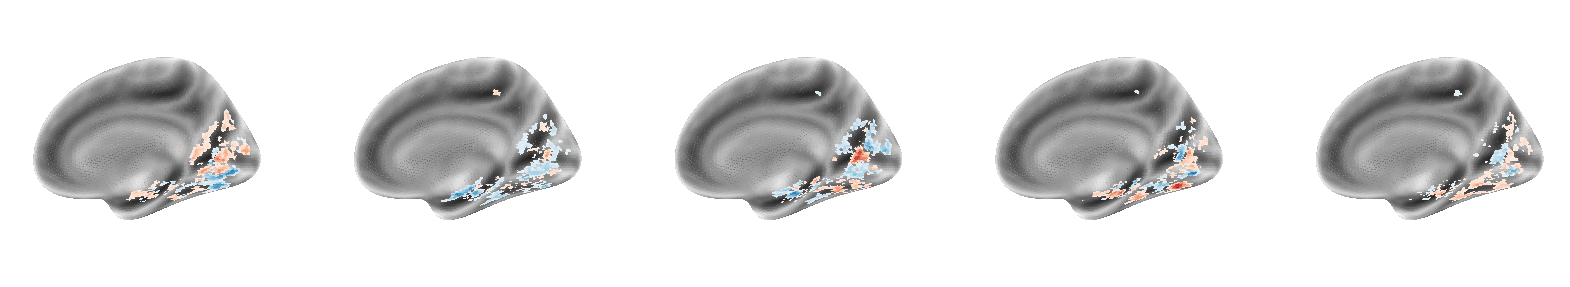

In [7]:
visualize_fmri_zscores(zscores_mean.numpy(), '../sample_data/roi/nsdgeneral.nii.gz', indices=np.arange(5))

In [12]:
# Let's give proper surface projections another try.
roi_mask_img = nib.load('../sample_data/roi/nsdgeneral.nii.gz')
roi_data = roi_mask_img.get_fdata()

zscore = zscores_mean[0].numpy()

# fsaverage
fsaverage = datasets.fetch_surf_fsaverage()
bg_right = fsaverage.sulc_right

zscores_restored = np.zeros(roi_data.shape)  # Initialize an array to hold the restored zscores 
zscores_restored[roi_data > 0] = zscore  # Fill in the zscores for the current image

zscores_img = nib.Nifti1Image(zscores_restored, affine=roi_mask_img.affine)

# Project your volume onto the surface (left and right hemispheres separately)
# texture_left = surface.vol_to_surf(zscores_img, fsaverage.pial_left)
texture_right_fs = surface.vol_to_surf(zscores_img, fsaverage.pial_right)


/Users/frederik/Repositories/cognition-computation/venv/lib/python3.11/site-packages/nilearn/surface/surface.py:1215: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


In [13]:
texture_right_fs.shape  # Should be (N,) where N is the number of vertices in the right hemisphere surface mesh

(10242,)

In [19]:
texture_right_native = surface.vol_to_surf(zscores_img, '../sample_data/freesurfer/subj01/surf/rh.pial')
texture_right_native.shape

(226601,)

## Surface plot on fsaverage

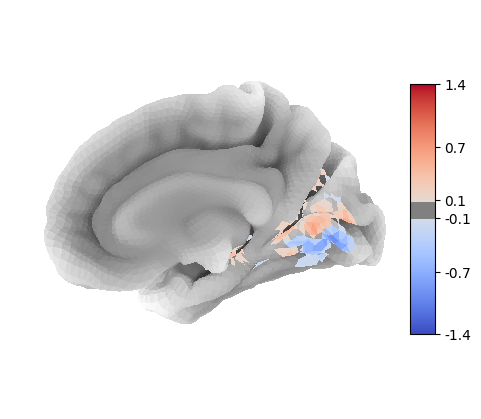

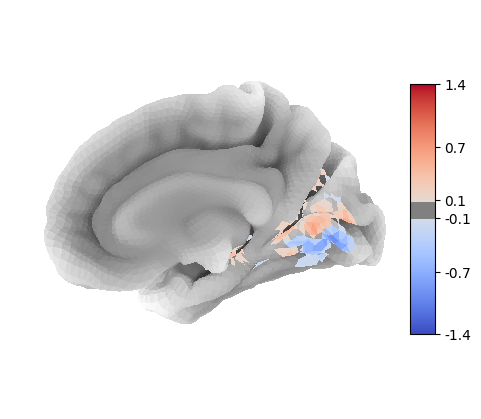

In [36]:
plotting.plot_surf_stat_map(
    fsaverage.pial_right, 
    texture_right_fs, 
    bg_map=fsaverage.sulc_right,
    hemi="right", 
    view="medial", 
    threshold=0.1, 
    cmap='coolwarm', 
    bg_on_data=False)

## Surface plot on subject-specific maps

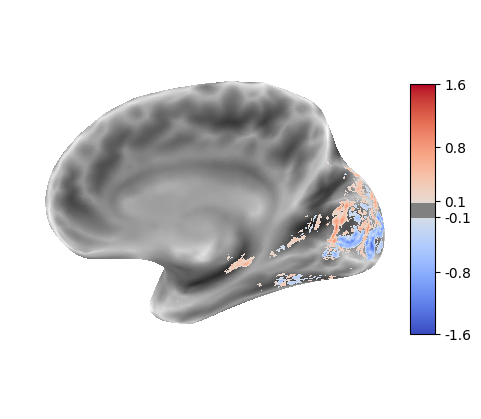

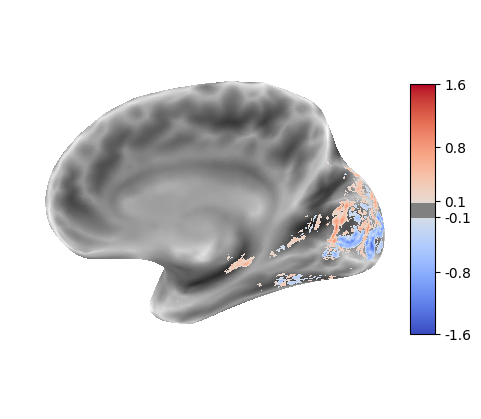

In [37]:
plotting.plot_surf_stat_map(
    '../sample_data/freesurfer/subj01/surf/rh.inflated', 
    texture_right_native,
    bg_map='../sample_data/freesurfer/subj01/surf/rh.sulc',
    hemi="right", 
    view="medial",
    threshold=0.1,
    cmap='coolwarm')

/var/folders/j1/w_rpygyd4gjckpxxhlmn1s4w0000gn/T/ipykernel_15143/352048907.py:10: UserWarning: You provided a non integer threshold but configured the colorbar to use integer formatting.
  plotting.plot_img_on_surf(


(<Figure size 426.667x480 with 5 Axes>,
 [<Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes3D: >, <Axes: >])

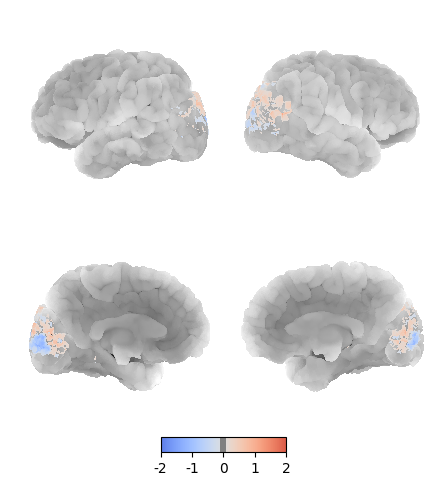

In [ ]:
surf_mesh = {
    'infl_left': '../sample_data/freesurfer/subj01/surf/lh.inflated',
    'infl_right': '../sample_data/freesurfer/subj01/surf/rh.inflated',
    'pial_left': '../sample_data/freesurfer/subj01/surf/lh.pial',
    'pial_right': '../sample_data/freesurfer/subj01/surf/rh.pial',
    'sulc_left': '../sample_data/freesurfer/subj01/surf/lh.sulc',
    'sulc_right': '../sample_data/freesurfer/subj01/surf/rh.sulc'
}

plotting.plot_img_on_surf(
    zscores_img,
    surf_mesh = surf_mesh,
    threshold=0.1, 
    cmap='coolwarm',
)

# Quantitative analysis

In [99]:
# According to ROIs specified in NSD dataset
# Different ROI text files exist, all defining integer values for the individual ROIs.
# We proceed by loading the ROI labels

ROI = "floc-places"

def get_rois(roiname):
    rois = {}
    with open(f'../sample_data/freesurfer/subj01/label/{ROI}.mgz.ctab', 'r') as f:
        # Each line contains the integer followed by the ROI name, separated by a space
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                roi_id, roi_name = parts
                rois[int(roi_id)] = roi_name

        f.close()
    return rois

In [93]:
# Next, we import the volumentric ROI mask
ROI_MASK = f"../sample_data/roi/{ROI}.nii.gz"

roi_mask_img = nib.load(ROI_MASK)
roi_mask_data = roi_mask_img.get_fdata()

# As a test, we count the number of voxels per ROI
for roi_id, roi_name in rois.items():
    num_voxels = np.sum(roi_mask_data == roi_id)
    print(f"ROI {roi_name} (ID: {roi_id}) has {num_voxels} voxels.")

ROI Unknown (ID: 0) has 103889 voxels.
ROI OPA (ID: 1) has 1611 voxels.
ROI PPA (ID: 2) has 1033 voxels.
ROI RSC (ID: 3) has 566 voxels.


In [76]:
roi_general_img = nib.load("../sample_data/roi/nsdgeneral.nii.gz")
roi_general_data = roi_general_img.get_fdata()
roi_general_data.shape

(81, 104, 83)

In [102]:
# As a short exercise we calculate zscore statistics for each ROI pretty-print them in a table
# Transform flattend voxels back to volumentric space
zscore = zscores[0]
zscore_restored = np.array([roi_general_data.copy() for _ in range(zscore.shape[0])])
for i in range(zscore_restored.shape[0]):
    zscore_restored[i][roi_data > 0] = zscore[i]


def calc_print_trial_means(roiname, rois):
    roi_mask = f"../sample_data/roi/{roiname}.nii.gz"
    
    roi_mask_img = nib.load(roi_mask)
    roi_mask_data = roi_mask_img.get_fdata()

    print(f"\nZ-score means per trial per  ROI in {roiname}:")
    # Table header
    print(f"| {'ROI Name':<20} | {'Voxel Count':<15} | {'T1 Mean':<15} | {'T2 Mean':<15} | {'T3 Mean':<15} |")
    print(f"|{'-'*22}|{'-'*17}|{'-'*17}|{'-'*17}|{'-'*17}|")
    for roi_id, roi_name in rois.items():
        if roi_id == 0:
            continue  # Skip the background
        else:
            num_voxels = np.sum(roi_mask_data == roi_id)
            if num_voxels == 0:
                print(f"| {roi_name:<20} | {'0':>15} | {'-':>15} | {'-':>15} | {'-':>15} |")
            else:
                # extract voxels of interest
                roi_voxels = zscore_restored[:, roi_mask_data == roi_id]
                # mean across voxels
                mean_trials = np.mean(roi_voxels, 1)
                print(f"| {roi_name:<20} | {num_voxels:>15} | {mean_trials[0]:>15.4f} | {mean_trials[1]:>15.4f} | {mean_trials[2]:>15.4f} |")

In [103]:
ROIS = [
    'floc-bodies',
    'floc-faces',
    'floc-places',
    'floc-words',
    'prf-visualrois'
]

for ROI in ROIS:
    rois = get_rois(ROI)
    calc_print_trial_means(ROI, rois)


Z-score means per trial per  ROI in floc-bodies:
| ROI Name             | Voxel Count     | T1 Mean         | T2 Mean         | T3 Mean         |
|----------------------|-----------------|-----------------|-----------------|-----------------|
| EBA                  |            2971 |          0.5229 |         -0.0573 |          0.2983 |
| FBA-1                |             396 |          0.4144 |         -0.2242 |          0.2285 |
| FBA-2                |             430 |          0.1448 |         -0.1187 |          0.1470 |
| mTL-bodies           |               0 |               - |               - |               - |

Z-score means per trial per  ROI in floc-faces:
| ROI Name             | Voxel Count     | T1 Mean         | T2 Mean         | T3 Mean         |
|----------------------|-----------------|-----------------|-----------------|-----------------|
| OFA                  |             355 |          0.3450 |         -0.7598 |          0.0241 |
| FFA-1                |    

In [1]:
# This frustratingly requires the full FreeSufer software to be installed. 
# cortex.freesurfer.import_subj('subj01', freesurfer_subject_dir='../sample_data/freesurfer/')